# Binary Classification with PyTorch — Why Non-Linearity Matters

Classifying `make_circles` data — two classes arranged as one ring 
inside another, which is NOT linearly separable. The goal isn't just a 
working classifier — it's to show what happens with no non-linear 
activation, and why adding one (ReLU) fixes it.

Three models, same basic shape, one key difference each time:
- **Model 0** — 2 linear layers, no activation
- **Model 1** — 3 linear layers, still no activation
- **Model 2** — 3 linear layers + ReLU

In [ ]:
import sklearn
from sklearn.datasets import make_circles

## Creating the Dataset

`make_circles` generates two classes shaped like one ring inside 
another. Visualizing it right away to confirm what we're dealing with.

In [ ]:
n_samples=1000

X,y = make_circles(n_samples,
                   noise = 0.03,
                   random_state=42
                   )

In [ ]:
len(X) , len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X :\n{X[:5]}")
print(f"First 5 samples of y :\n{y[:5]}")

First 5 samples of X :
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y :
[1 1 1 1 0]


In [ ]:
import pandas as pd

circles = pd.DataFrame({"X1" : X[:,0],
                       "X2" : X[:,1],
                       "label" : y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


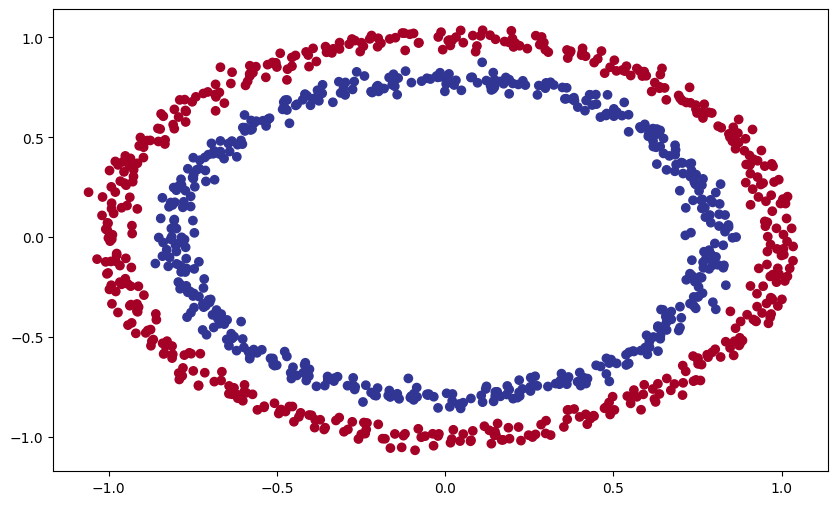

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu)

**Observation:** the two classes form concentric circles — no straight 
line anywhere separates them. That's the whole point of this notebook: 
a model built only from linear layers should struggle here, no matter 
how many layers it has.

In [ ]:
X.shape , y.shape

((1000, 2), (1000,))

In [ ]:
import torch
from torch import nn
torch.__version__

'2.11.0+cpu'

In [ ]:
type(X) , type(y)

(numpy.ndarray, numpy.ndarray)

In [ ]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
type(X) , type(y)


(torch.Tensor, torch.Tensor)

## Preparing the Data for PyTorch

Converting the numpy arrays to tensors, splitting into train/test 
(80/20), and checking which device is available.

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train) , len(X_test) , len(y_train) , len(y_test)

(800, 200, 800, 200)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"the currect device is {device}")

the currect device is cpu


## Model 0: Baseline — Two Linear Layers, No Activation

Two `nn.Linear` layers stacked directly, nothing in between. Using 
`BCEWithLogitsLoss` since this is binary. Hypothesis: stacking linear 
layers with no activation is mathematically still just one linear 
transformation, so this shouldn't be able to learn a circular boundary 
at all.

In [ ]:
from sklearn import datasets

class CirclelModelV0(nn.Module) :

  def __init__(self):

    super().__init__()

    self.layer_1 = nn.Linear(in_features=2,out_features=5)
    self.layer_2 = nn.Linear(in_features=5,out_features=1)




  def forward(self, x:torch.Tensor) -> torch.Tensor :

    return self.layer_2(self.layer_1(x))

model_0 = CirclelModelV0()
model_0

CirclelModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.3544,  0.1427],
                      [ 0.5123,  0.3425],
                      [-0.1715,  0.4949],
                      [-0.2535,  0.5546],
                      [ 0.3842,  0.0755]])),
             ('layer_1.bias',
              tensor([-0.2583, -0.3624,  0.2148,  0.3545,  0.4592])),
             ('layer_2.weight',
              tensor([[-0.2237, -0.2805,  0.2116, -0.3420,  0.0903]])),
             ('layer_2.bias', tensor([0.1417]))])

In [ ]:
with torch.inference_mode():
  untrained_preds = model_0(X_test)
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"InFirst 10 predictions: \n {untrained_preds[: 10]}")
print(f"InFirst 10 labels: {y_test}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])
InFirst 10 predictions: 
 tensor([[0.1778],
        [0.0668],
        [0.4286],
        [0.1069],
        [0.3647],
        [0.2974],
        [0.0354],
        [0.0893],
        [0.4309],
        [0.0587]])
InFirst 10 labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
        1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1.,
        1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
        1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
        0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
        1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.,
        0., 0., 1., 0

**Observation:** accuracy sits around 50% the whole time — basically a 
coin flip. Confirms the hypothesis: no activation means the model can 
only draw a straight line, and no straight line separates these circles.

In [ ]:
from torch import nn

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [ ]:
def accuracy_fn(y_true, y_pred):

  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

In [ ]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test)

y_logits

tensor([[0.1778],
        [0.0668],
        [0.4286],
        [0.1069],
        [0.3647],
        [0.2974],
        [0.0354],
        [0.0893],
        [0.4309],
        [0.0587],
        [0.1693],
        [0.1474],
        [0.0574],
        [0.4657],
        [0.4432],
        [0.1759],
        [0.0731],
        [0.2139],
        [0.2359],
        [0.2855],
        [0.0616],
        [0.1730],
        [0.2705],
        [0.2560],
        [0.0253],
        [0.0685],
        [0.4979],
        [0.2558],
        [0.4533],
        [0.4538],
        [0.0827],
        [0.0198],
        [0.1466],
        [0.4229],
        [0.1602],
        [0.0883],
        [0.1325],
        [0.4588],
        [0.4478],
        [0.4637],
        [0.2830],
        [0.4045],
        [0.0783],
        [0.3922],
        [0.1350],
        [0.0780],
        [0.3475],
        [0.0569],
        [0.1086],
        [0.3247],
        [0.1158],
        [0.1261],
        [0.2233],
        [0.4211],
        [0.1075],
        [0

In [ ]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5443],
        [0.5167],
        [0.6055],
        [0.5267],
        [0.5902],
        [0.5738],
        [0.5089],
        [0.5223],
        [0.6061],
        [0.5147],
        [0.5422],
        [0.5368],
        [0.5144],
        [0.6144],
        [0.6090],
        [0.5439],
        [0.5183],
        [0.5533],
        [0.5587],
        [0.5709],
        [0.5154],
        [0.5431],
        [0.5672],
        [0.5636],
        [0.5063],
        [0.5171],
        [0.6220],
        [0.5636],
        [0.6114],
        [0.6116],
        [0.5207],
        [0.5049],
        [0.5366],
        [0.6042],
        [0.5400],
        [0.5221],
        [0.5331],
        [0.6127],
        [0.6101],
        [0.6139],
        [0.5703],
        [0.5998],
        [0.5196],
        [0.5968],
        [0.5337],
        [0.5195],
        [0.5860],
        [0.5142],
        [0.5271],
        [0.5805],
        [0.5289],
        [0.5315],
        [0.5556],
        [0.6038],
        [0.5268],
        [0

In [ ]:
y_preds = torch.round(y_pred_probs)
y_preds.squeeze()

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.])

In [ ]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs) :

  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)

  accuracy = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():

    test_logits = model_0(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,
                        y_test)

    test_accuracy = accuracy_fn(y_true=y_test,
                                y_pred = test_pred)

  if epoch%10==0 :
    print(f"Epoch : {epoch} | Loss : {loss:.5f} | Accuracy : {accuracy:.2f}% | Test Loss : {test_loss:.5f} | Test Acc : {test_accuracy:.2f}%")

Epoch : 0 | Loss : 0.70672 | Accuracy : 50.00% | Test Loss : 0.69785 | Test Acc : 50.00%
Epoch : 10 | Loss : 0.70045 | Accuracy : 57.00% | Test Loss : 0.69326 | Test Acc : 54.00%
Epoch : 20 | Loss : 0.69769 | Accuracy : 52.25% | Test Loss : 0.69160 | Test Acc : 53.00%
Epoch : 30 | Loss : 0.69632 | Accuracy : 50.75% | Test Loss : 0.69105 | Test Acc : 53.50%
Epoch : 40 | Loss : 0.69554 | Accuracy : 50.62% | Test Loss : 0.69093 | Test Acc : 54.50%
Epoch : 50 | Loss : 0.69503 | Accuracy : 50.25% | Test Loss : 0.69099 | Test Acc : 54.50%
Epoch : 60 | Loss : 0.69466 | Accuracy : 49.62% | Test Loss : 0.69111 | Test Acc : 54.50%
Epoch : 70 | Loss : 0.69438 | Accuracy : 49.25% | Test Loss : 0.69127 | Test Acc : 53.00%
Epoch : 80 | Loss : 0.69415 | Accuracy : 49.00% | Test Loss : 0.69144 | Test Acc : 54.50%
Epoch : 90 | Loss : 0.69396 | Accuracy : 49.25% | Test Loss : 0.69162 | Test Acc : 54.00%


In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print ("helper_functions. py already exists, skipping download")
else:
  print ("Download helper_functions-py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py" , "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions , plot_decision_boundary

Download helper_functions-py


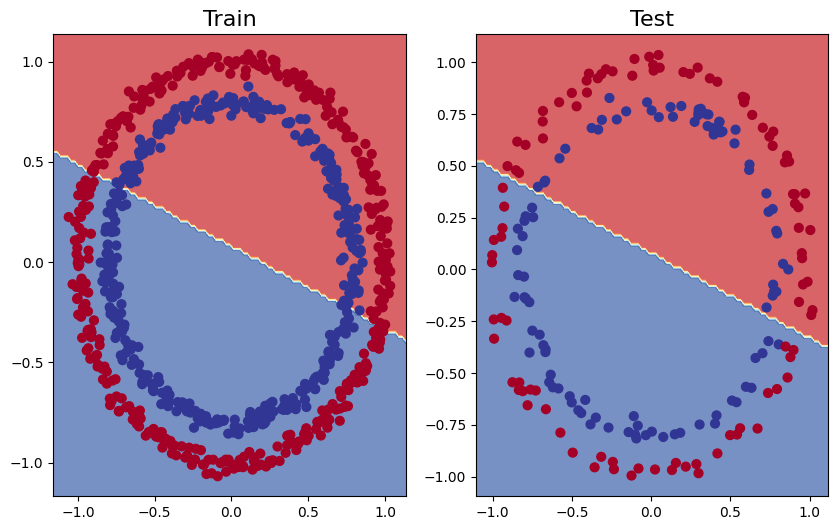

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title("Train",fontsize=16)
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test",fontsize=16)
plot_decision_boundary(model_0,X_test,y_test)

**Observation:** the plot backs this up — no attempt at a circular 
shape, the model is just guessing one class for almost everything.

## Model 1: Adding Depth, Still No Activation

Same idea as Model 0, but 3 linear layers instead of 2 — testing 
whether more layers alone (without activation) helps.

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

  def forward(self,x) :
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_1.parameters(),
                         lr=0.05)

In [ ]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs) :

  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)

  accuracy = accuracy_fn(y_true=y_train,
                          y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()
  with torch.inference_mode():

    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)

    test_acc = accuracy_fn(y_true=y_test,
                           y_pred = test_pred)

  if epoch%100==0 :

    print(f"Epoch : {epoch} | Loss : {loss:.5f} | Accuracy : {accuracy:.2f}% | Test Loss : {test_loss:.5f} | Test Accuracy : {test_acc:.2f}%")



Epoch : 0 | Loss : 0.69396 | Accuracy : 50.88% | Test Loss : 0.69261 | Test Accuracy : 51.00%
Epoch : 100 | Loss : 0.69322 | Accuracy : 49.88% | Test Loss : 0.69323 | Test Accuracy : 50.00%
Epoch : 200 | Loss : 0.69305 | Accuracy : 50.50% | Test Loss : 0.69378 | Test Accuracy : 48.50%
Epoch : 300 | Loss : 0.69300 | Accuracy : 51.00% | Test Loss : 0.69415 | Test Accuracy : 47.00%
Epoch : 400 | Loss : 0.69299 | Accuracy : 51.12% | Test Loss : 0.69437 | Test Accuracy : 46.00%
Epoch : 500 | Loss : 0.69298 | Accuracy : 51.62% | Test Loss : 0.69450 | Test Accuracy : 46.00%
Epoch : 600 | Loss : 0.69298 | Accuracy : 51.62% | Test Loss : 0.69458 | Test Accuracy : 45.00%
Epoch : 700 | Loss : 0.69298 | Accuracy : 51.12% | Test Loss : 0.69462 | Test Accuracy : 45.50%
Epoch : 800 | Loss : 0.69298 | Accuracy : 51.12% | Test Loss : 0.69464 | Test Accuracy : 46.00%
Epoch : 900 | Loss : 0.69298 | Accuracy : 51.00% | Test Loss : 0.69466 | Test Accuracy : 46.00%


**Observation:** still stuck around 50% accuracy, even with an extra 
layer and 10x more epochs. Confirms depth alone doesn't matter — 
without non-linearity, stacking more linear layers is still just one 
linear function in disguise.

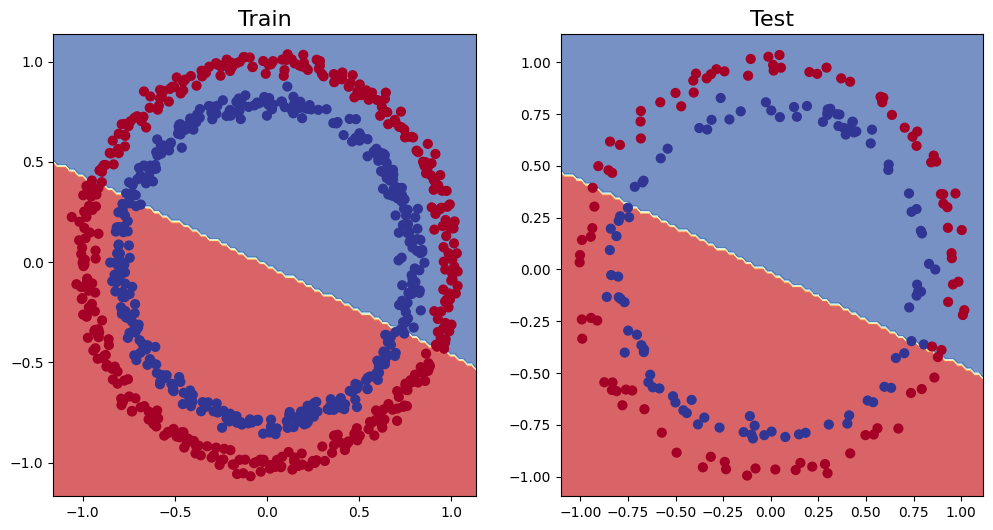

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Train",fontsize=16)
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test",fontsize=16)
plot_decision_boundary(model_1,X_test,y_test)

**Observation:** same story as Model 0 — no real attempt at a circular 
boundary.

## Model 2: Adding Non-Linearity (ReLU)

Same architecture as Model 1, but with `ReLU` between the linear 
layers. This is the one change that should let the model learn curved, 
non-linear boundaries instead of straight lines.

In [ ]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)
    self.relu = nn.ReLU()

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2()
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.05)

In [ ]:
torch.manual_seed(42)

epochs = 4000

for epoch in range(epochs):

  model_3.train()

  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)

  accuracy = accuracy_fn(y_true=y_train,
                         y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()


  model_3.eval()
  with torch.inference_mode():

    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)

    test_accuracy = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)

  if epoch%100==0:

    print(f"Epoch : {epoch} | Loss : {loss:.5f} | Accuracy : {accuracy:.2f}% | Test Loss : {test_loss:.5f} | Test Accuracy : {test_accuracy:.2f}%")

Epoch : 0 | Loss : 0.69295 | Accuracy : 50.00% | Test Loss : 0.69322 | Test Accuracy : 50.00%
Epoch : 100 | Loss : 0.69181 | Accuracy : 58.38% | Test Loss : 0.69178 | Test Accuracy : 59.50%
Epoch : 200 | Loss : 0.69115 | Accuracy : 52.88% | Test Loss : 0.69103 | Test Accuracy : 52.50%
Epoch : 300 | Loss : 0.69050 | Accuracy : 52.88% | Test Loss : 0.69027 | Test Accuracy : 55.00%
Epoch : 400 | Loss : 0.68977 | Accuracy : 53.37% | Test Loss : 0.68940 | Test Accuracy : 55.00%
Epoch : 500 | Loss : 0.68894 | Accuracy : 53.50% | Test Loss : 0.68841 | Test Accuracy : 56.00%
Epoch : 600 | Loss : 0.68795 | Accuracy : 53.00% | Test Loss : 0.68724 | Test Accuracy : 56.00%
Epoch : 700 | Loss : 0.68676 | Accuracy : 52.62% | Test Loss : 0.68588 | Test Accuracy : 56.50%
Epoch : 800 | Loss : 0.68516 | Accuracy : 52.75% | Test Loss : 0.68413 | Test Accuracy : 56.50%
Epoch : 900 | Loss : 0.68325 | Accuracy : 52.75% | Test Loss : 0.68199 | Test Accuracy : 56.00%
Epoch : 1000 | Loss : 0.68101 | Accuracy :

**Observation:** accuracy climbs well past 50% and keeps improving 
through training — a completely different result from the first two 
models. The only thing that changed was ReLU, which is exactly why it 
matters.

In [ ]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
        1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1.,
        1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
        1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
        0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
        1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.,
        0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1.,
        1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
        0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0.,
        1., 1.])

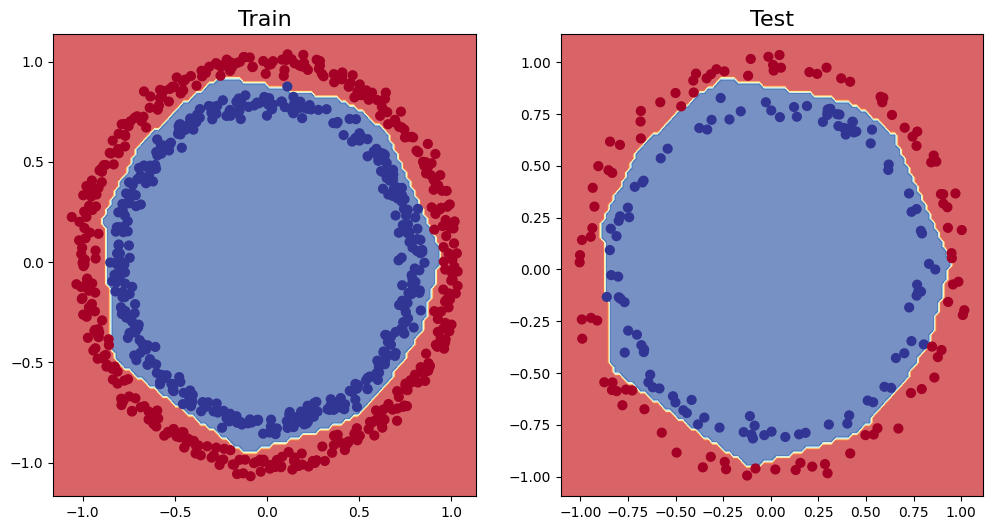

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Train",fontsize=16)
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test",fontsize=16)
plot_decision_boundary(model_3,X_test,y_test)

**Observation:** the boundary now actually curves around the inner 
circle — the model has learned the real shape of the data.

## Key Takeaway

Stacking linear layers, no matter how many, can never learn a 
non-linear pattern — it's mathematically equivalent to a single linear 
layer. A non-linear activation function like ReLU is what actually 
gives a network the ability to learn curved decision boundaries. Depth 
without non-linearity is wasted depth.